# Read in and format the Pisa tracks then use it to plot

In [7]:
import os, glob, re
import numpy as np
import scipy.io

import sys
sys.path.append(os.path.abspath("/Users/dingshandeng/github/ysoisochrone"))

import ysoisochrone
from ysoisochrone import utils  # uses your existing create_meshgrid/save_as_mat

pisa_dir = "./isochrones_data/Pisa"
files = sorted(glob.glob(os.path.join(pisa_dir, "TRK_*.DAT")))

print("N files:", len(files))
print("Example:", os.path.basename(files[0]) if files else None)
assert len(files) > 0, "No TRK_*.DAT files found."

N files: 43
Example: TRK_M0.20_Z0.01377_Y0.2533_XD2E5_ML1.68_AS05.DAT


In [2]:
def read_pisa_dat_file_to_points(file_path):
    """
    Read Pisa DAT file and return arrays:
      mass, log_age, teff (K), logL
    """
    arr = np.genfromtxt(file_path, comments="#")
    if arr.ndim == 1:
        arr = arr[None, :]

    log_age = arr[:, 1].astype(float)
    log_l   = arr[:, 3].astype(float)
    log_te  = arr[:, 4].astype(float)

    teff = 10**log_te  # convert back to Teff in Kelvin so utils.create_meshgrid works

    return log_age, teff, log_l

In [16]:
data_points = []

for fp in files:
    base = os.path.basename(fp)
    m = re.search(r"TRK_M([0-9]*\.?[0-9]+)", base)
    if m is None:
        raise ValueError(f"Cannot parse mass from filename: {base}")
    mass = float(m.group(1))

    log_age, teff, log_l = read_pisa_dat_file_to_points(fp)

    pts = np.column_stack([
        np.full_like(log_age, mass, dtype=float),
        log_age,
        teff,
        log_l
    ])
    data_points.append(pts)

data_points = np.vstack(data_points)
print("data_points shape:", data_points.shape)  # (N_total_rows, 4)
print("mass range:", data_points[:,0].min(), data_points[:,0].max())
print("log_age range:", data_points[:,1].min(), data_points[:,1].max())
print("Teff range:", data_points[:,2].min(), data_points[:,2].max())
print("log_l range:", data_points[:,3].min(), data_points[:,3].max())

data_points shape: (55663, 4)
mass range: 0.2 7.0
log_age range: 3.88992313 10.7925377
Teff range: 3228.345447487264 21801.681963800984
log_l range: -2.30996 3.56371


In [20]:
masses_i, log_age_i, logtlogl_grid, masses_grid, log_age_grid = utils.create_meshgrid(
    data_points,
    min_age=0.5,     # Myr
    max_age=1000.0,  # Myr
    min_mass=0.0,
    max_mass=7.5,
    interpolation_method="linear"
)

print("masses_i:", masses_i.shape, "range:", masses_i.min(), masses_i.max())
print("log_age_i:", log_age_i.shape, "range:", log_age_i.min(), log_age_i.max())
print("logtlogl_grid:", logtlogl_grid.shape)  # should be (N_age, N_mass, 2) per your create_meshgrid

masses_i: (156,) range: 0.20000000000000004 7.096267784671532
log_age_i: (332,) range: 5.698970004336019 9.008970004335948
logtlogl_grid: (332, 156, 2)


In [21]:
out_file = "./isochrones_data/Pisa_AgeMassGrid_YSO_builtin_matrix.mat"

utils.save_as_mat(
    masses_i,
    log_age_i,
    logtlogl_grid,
    out_file
)

print("Saved:", out_file)

Data saved to ./isochrones_data/Pisa_AgeMassGrid_YSO_builtin_matrix.mat
Saved: ./isochrones_data/Pisa_AgeMassGrid_YSO_builtin_matrix.mat


In [24]:
d = scipy.io.loadmat(out_file)
mass = np.asarray(d["mass"]).squeeze()
log_age = np.asarray(d["log_age"]).squeeze()
logt_logl = d["logt_logl"]

print("mass:", mass.shape)
print("log_age:", log_age.shape)
print("logt_logl:", logt_logl.shape)  # should be (N_age, N_mass, 2)

mass: (156,)
log_age: (332,)
logt_logl: (332, 156, 2)


## Read in the Pisa File

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
df_prop = pd.read_csv('./example_targets.csv', skiprows=6)

# For test targets from Lupus
toobright = [] # ['0']  
toofaint = [] # ['0']
median_age = 1.0 # Myrs	

err_Teff = ysoisochrone.utils.assign_unc_teff(df_prop['Teff[K]'].values)
err_Lumi = ysoisochrone.utils.assign_unc_lumi(df_prop['Luminosity[Lsun]'].values)
df_prop['e_Teff[K]'] = err_Teff
df_prop['e_Luminosity[Lsun]'] = err_Lumi

# you need to specify the source names
toobright = ['J11065906-7718535','J11094260-7725578',
   		     'J11105597-7645325','J11183572-7935548']
toofaint = ['J10533978-7712338','J11063945-7736052','J11082570-7716396',
            'J11111083-7641574','J11160287-7624533']

# the median age for Cham I star-forming region
median_age = 6.48 # Myrs, the age took from Pasucci+2016 choice

# form the df_toobright and df_toofaint only for plot
idx_toobright = []
idx_toofaint  = []
for idx_t in df_prop.index:
    if df_prop.loc[idx_t, 'Source'] in toobright:
        idx_toobright.append(idx_t)
    if df_prop.loc[idx_t, 'Source'] in toofaint:
        idx_toofaint.append(idx_t)

df_toobright = df_prop.loc[idx_toobright]
df_toofaint = df_prop.loc[idx_toofaint]

using the built in isochrones
-----------------------
using the user-specified isochrone matrix of
./isochrones_data/Pisa_AgeMassGrid_YSO_builtin_matrix.mat
-----------------------
(156,) (332,) (332, 156, 2)


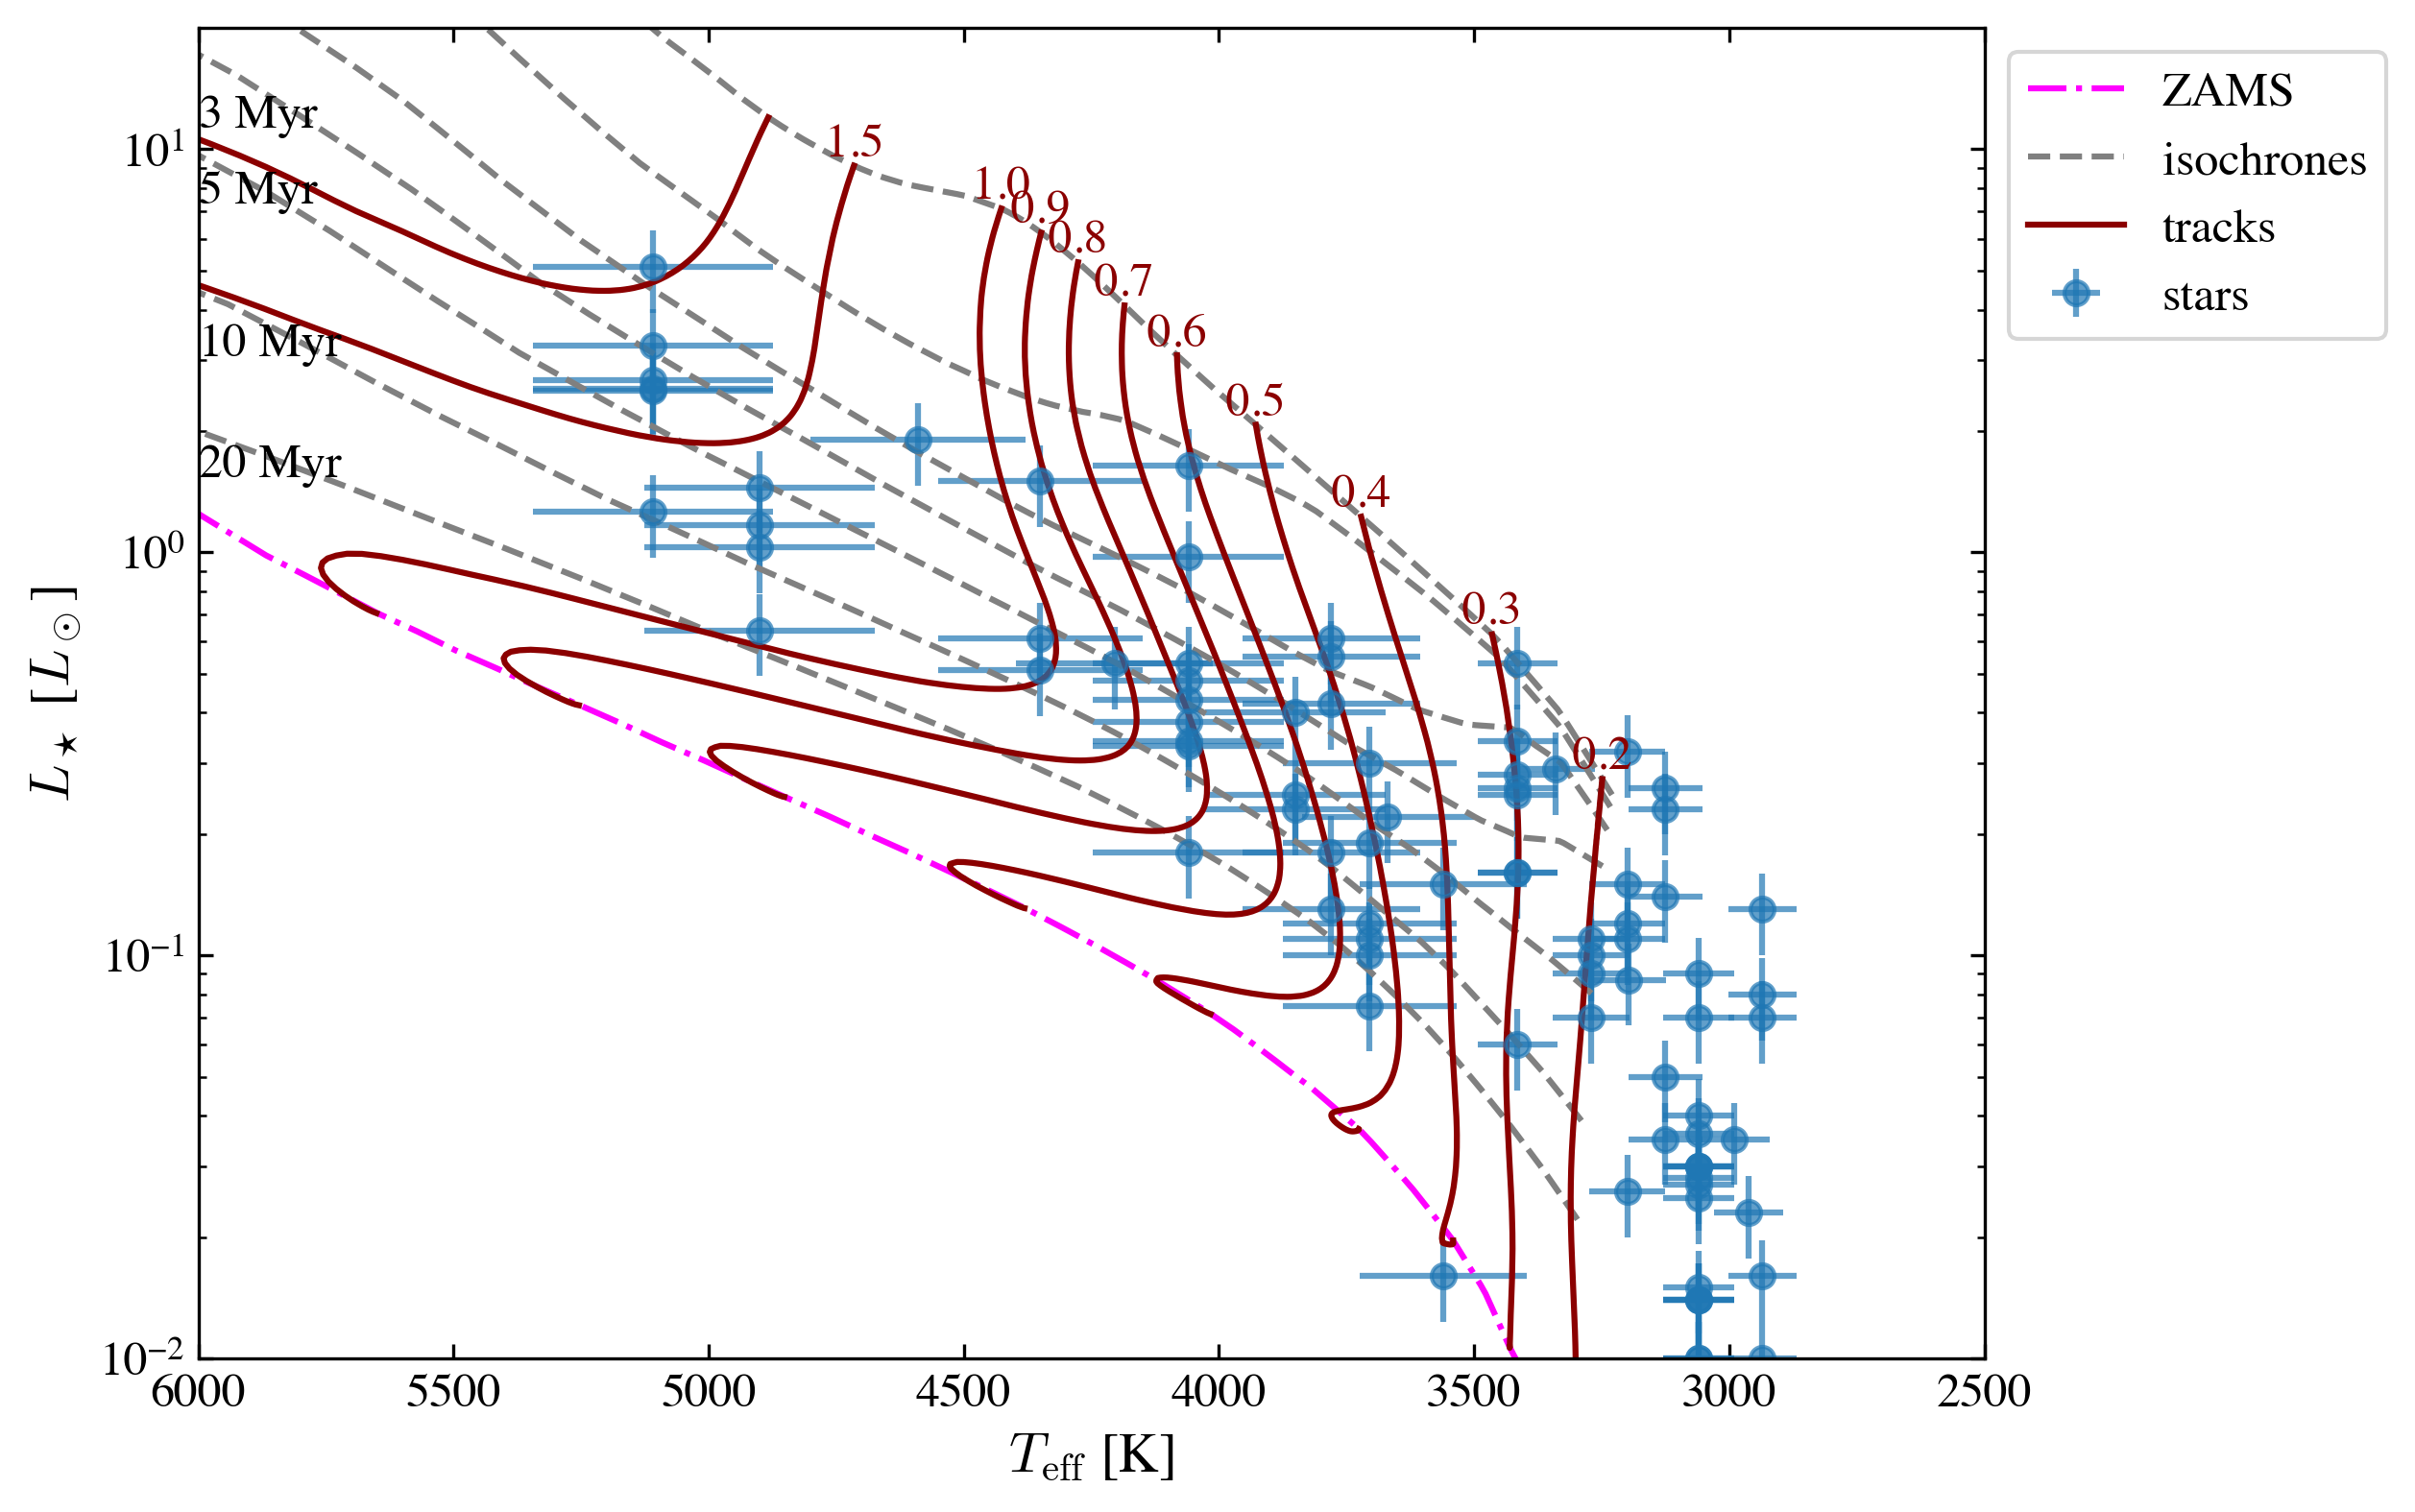

In [39]:
import ysoisochrone
from ysoisochrone.isochrone import Isochrone
import matplotlib.pyplot as plt

isochrone = Isochrone()
isochrone.set_tracks("customize", load_file=out_file)

print(isochrone.masses.shape, isochrone.log_age.shape, isochrone.logtlogl.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ysoisochrone.plotting.plot_hr_diagram(
    isochrone, df_prop, ax_set=ax,
    ages_to_plot=[0.5e6, 1.0e6, 2.0e6, 3.0e6, 5.0e6, 10.0e6, 20.0e6],
    masses_to_plot=[0.21, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0],
    xlim_set=[6000, 2500], ylim_set=[0.01, 20.0],
)
plt.show()